<a href="https://colab.research.google.com/github/sbsreyes/Proyecto-Despliegue_de_soluciones-Team-24/blob/master/BiLSTM_corregido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**BiLSTM**

In [ ]:
# ── Celda 1: Verificar GPU y instalar dependencias ────────────────────────────
import torch
print(f'GPU disponible: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU"}')

!pip install gdown --quiet

GPU disponible: True
GPU: Tesla T4


**Celda 2 — Importar librerías y cargar datos:**

In [ ]:
import pandas as pd
import numpy as np
import gdown
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (fbeta_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report,
                              precision_recall_fscore_support)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando: {DEVICE}')

# Cargar dataset completo
gdown.download('https://drive.google.com/uc?id=1S76FGFaw6Sywj-sfOWcl6UqOCsbb1M2i',
               'dataset_dengue_completo.csv', quiet=False)

df = pd.read_csv('dataset_dengue_completo.csv')
df['cod_municipio'] = df['cod_municipio'].astype(str).str.zfill(5)
print(f'Dataset: {len(df):,} filas | Años: {sorted(df["anio"].unique())}')

Usando: cuda


Downloading...
From: https://drive.google.com/uc?id=1S76FGFaw6Sywj-sfOWcl6UqOCsbb1M2i
To: /content/dataset_dengue_completo.csv
100%|██████████| 42.9M/42.9M [00:00<00:00, 72.5MB/s]


Dataset: 257,482 filas | Años: [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024)]


**Celda 3 — Preparar datos con el mismo pipeline del XGBoost:**

In [ ]:
from sklearn.preprocessing import LabelEncoder

COLS_CLIMA = ['temp_media_c','humedad_pct','precip_mm',
              'temp_lag2','temp_lag3','temp_lag4',
              'precip_lag2','precip_lag3','precip_lag4',
              'humedad_lag1','humedad_lag2','humedad_lag3']

# ── Agregar a nivel municipal ─────────────────────────────────────────────────
df_mun = (df.groupby(['cod_municipio','NOM_MPIO','NOM_DPTO',
                       'anio','semana_epi','altitud_msnm',
                       'cat_altitud','poblacion'] + COLS_CLIMA)
          .agg(casos=('casos','sum'))
          .reset_index()
)
df_mun['split'] = df_mun['anio'].apply(lambda x: 'train' if x <= 2019 else 'test')

# ── Municipios válidos ────────────────────────────────────────────────────────
df_train_mun = df_mun[df_mun['anio'].isin(range(2009, 2017))]
semanas_por_mun = df_train_mun[df_train_mun['casos'] > 0].groupby('cod_municipio').size()
municipios_validos = semanas_por_mun[semanas_por_mun >= 20].index
print(f'Municipios válidos: {len(municipios_validos)}')

# ── Grilla completa ───────────────────────────────────────────────────────────
info_mun = (df_mun[df_mun['cod_municipio'].isin(municipios_validos)]
            [['cod_municipio','NOM_MPIO','NOM_DPTO','altitud_msnm','cat_altitud']]
            .drop_duplicates('cod_municipio'))

todos_años = list(range(2009, 2020)) + [2022, 2023, 2024]
grilla = pd.MultiIndex.from_product(
    [municipios_validos, todos_años, range(1, 53)],
    names=['cod_municipio', 'anio', 'semana_epi']
).to_frame(index=False)

casos_ref = (df_mun[df_mun['cod_municipio'].isin(municipios_validos)]
             [['cod_municipio','anio','semana_epi','casos']]
             .drop_duplicates(['cod_municipio','anio','semana_epi']))
clima_ref = (df_mun[df_mun['cod_municipio'].isin(municipios_validos)]
             [['cod_municipio','anio','semana_epi'] + COLS_CLIMA]
             .drop_duplicates(['cod_municipio','anio','semana_epi']))
pob_ref = (df_mun[df_mun['cod_municipio'].isin(municipios_validos)]
           .groupby(['cod_municipio','anio'])['poblacion'].first().reset_index())

df_completo = grilla.copy()
df_completo = df_completo.merge(casos_ref, on=['cod_municipio','anio','semana_epi'], how='left')
df_completo['casos'] = df_completo['casos'].fillna(0)
df_completo = df_completo.merge(pob_ref,   on=['cod_municipio','anio'], how='left')
df_completo = df_completo.merge(clima_ref, on=['cod_municipio','anio','semana_epi'], how='left')
df_completo = df_completo.merge(info_mun,  on='cod_municipio', how='left')

df_completo = df_completo.sort_values(['cod_municipio','anio','semana_epi'])
for col in COLS_CLIMA:
    df_completo[col] = (df_completo.groupby('cod_municipio')[col]
                        .transform(lambda x: x.interpolate().ffill().bfill()))

# ── Canal endémico ────────────────────────────────────────────────────────────
df_train_completo   = df_completo[df_completo['anio'].isin(range(2009, 2017))]
df_train_con_casos  = df_train_completo[df_train_completo['casos'] > 0]

canal_mun = (df_train_con_casos.groupby(['cod_municipio','semana_epi'])['casos']
             .agg(p25=lambda x: x.quantile(0.25),
                  mediana=lambda x: x.quantile(0.50),
                  p75=lambda x: x.quantile(0.75))
             .reset_index())

def clasificar_zona_v2(row):
    if pd.isna(row['p25']): return 'seguridad'
    if row['p75'] == 0 and row['casos'] == 0: return 'seguridad'
    if row['p25'] == row['p75']:
        if row['casos'] > row['p75']:   return 'epidemica'
        elif row['casos'] == row['p75'] and row['casos'] > 0: return 'alerta'
        elif row['casos'] == 0:         return 'seguridad'
        else:                           return 'exito'
    if row['casos'] >= row['p75']:      return 'epidemica'
    elif row['casos'] >= row['mediana']: return 'alerta'
    elif row['casos'] >= row['p25']:    return 'exito'
    else:                               return 'seguridad'

df_modelo = df_completo.merge(canal_mun, on=['cod_municipio','semana_epi'], how='left')
df_modelo[['p25','mediana','p75']] = df_modelo[['p25','mediana','p75']].fillna(0)
df_modelo['zona_canal'] = df_modelo.apply(clasificar_zona_v2, axis=1)
df_modelo['alerta'] = df_modelo['zona_canal'].map(
    {'epidemica':1,'alerta':1,'exito':0,'seguridad':0})

# ── Variables adicionales ─────────────────────────────────────────────────────
df_modelo = df_modelo.sort_values(['cod_municipio','anio','semana_epi'])

for lag in [1,2,3,4]:
    df_modelo[f'casos_lag{lag}'] = (df_modelo.groupby('cod_municipio')['casos'].shift(lag))
df_modelo['casos_ma4'] = (df_modelo.groupby('cod_municipio')['casos']
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean()))
df_modelo['casos_tendencia'] = df_modelo['casos_lag1'] - df_modelo['casos_lag2']
df_modelo['grados_dia']      = (df_modelo['temp_media_c'] - 18).clip(lower=0)
df_modelo['indice_idoneidad'] = (df_modelo['temp_media_c'] *
    (1 / (1 + np.exp(0.003 * (df_modelo['altitud_msnm'] - 2200)))))
df_modelo['semana_sin'] = np.sin(2 * np.pi * df_modelo['semana_epi'] / 52)
df_modelo['semana_cos'] = np.cos(2 * np.pi * df_modelo['semana_epi'] / 52)

# LabelEncoder fit SOLO con datos de train (2009-2016)
le = LabelEncoder()
categorias_train = (df_modelo[df_modelo['anio'].isin(range(2009,2017))]
                    ['cat_altitud'].fillna('Sin dato').unique())
le.fit(categorias_train)
df_modelo['cat_altitud_enc'] = le.transform(
    df_modelo['cat_altitud'].fillna('Sin dato'))

print(f'Dataset modelo: {len(df_modelo):,} filas')
print(f'% alerta global: {df_modelo["alerta"].mean()*100:.1f}%')
print(f'Train: {(df_modelo["anio"].isin(range(2009,2017))).sum():,}')
print(f'Val  : {(df_modelo["anio"].isin(range(2017,2020))).sum():,}')
print(f'Test : {(df_modelo["anio"].isin([2022,2023,2024])).sum():,}')

Municipios válidos: 651
Dataset modelo: 473,928 filas
% alerta global: 17.4%
Train: 270,816
Val  : 101,556
Test : 101,556


**Celda 4 — Construir secuencias para BiLSTM:**

In [ ]:
# ── Construir secuencias temporales ───────────────────────────────────────────
# El BiLSTM necesita secuencias de N semanas consecutivas
# Para cada municipio y semana t, usamos las últimas WINDOW semanas como input
# y predecimos si la semana t+1 será alerta

WINDOW = 8  # últimas 8 semanas de historia

FEATURES_LSTM = [
    'altitud_msnm', 'cat_altitud_enc', 'semana_sin', 'semana_cos',
    'temp_media_c', 'humedad_pct', 'precip_mm',
    'grados_dia', 'indice_idoneidad',
    'temp_lag2', 'temp_lag3', 'temp_lag4',
    'precip_lag2', 'precip_lag3', 'precip_lag4',
    'humedad_lag1', 'humedad_lag2', 'humedad_lag3',
    'casos_lag1', 'casos_lag2', 'casos_lag3', 'casos_lag4',
    'casos_ma4', 'casos_tendencia',
    'poblacion'
]

N_FEATURES = len(FEATURES_LSTM)
print(f'Features: {N_FEATURES}')
print(f'Window  : {WINDOW} semanas')

# Normalizar features (importante para LSTM)
from sklearn.preprocessing import StandardScaler

df_modelo_sorted = df_modelo.sort_values(['cod_municipio','anio','semana_epi']).copy()
df_modelo_sorted = df_modelo_sorted.dropna(subset=FEATURES_LSTM + ['alerta'])

# StandardScaler fit SOLO con datos de train (2009-2016)
# CRÍTICO: el scaler debe aprender la escala solo del conjunto de entrenamiento
# para no introducir información del período de test en la normalización
df_train_scale = df_modelo_sorted[df_modelo_sorted['anio'].isin(range(2009,2017))]
scaler = StandardScaler()
scaler.fit(df_train_scale[FEATURES_LSTM])
df_modelo_sorted[FEATURES_LSTM] = scaler.transform(
    df_modelo_sorted[FEATURES_LSTM])

print(f'Filas después de limpiar nulos: {len(df_modelo_sorted):,}')

# ── Crear secuencias por municipio ────────────────────────────────────────────
def crear_secuencias(df, municipios, años, window):
    X_seq, y_seq = [], []
    df_sub = df[df['cod_municipio'].isin(municipios) &
                df['anio'].isin(años)].copy()

    for mun in df_sub['cod_municipio'].unique():
        df_mun = df_sub[df_sub['cod_municipio'] == mun].reset_index(drop=True)
        valores = df_mun[FEATURES_LSTM].values
        alertas = df_mun['alerta'].values

        for i in range(window, len(df_mun)):
            X_seq.append(valores[i-window:i])
            y_seq.append(alertas[i])

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

print('Creando secuencias de entrenamiento...')
X_tr, y_tr = crear_secuencias(
    df_modelo_sorted, municipios_validos,
    list(range(2009, 2017)), WINDOW)

print('Creando secuencias de validación...')
X_val, y_val = crear_secuencias(
    df_modelo_sorted, municipios_validos,
    list(range(2017, 2020)), WINDOW)

print('Creando secuencias de test...')
X_te, y_te = crear_secuencias(
    df_modelo_sorted, municipios_validos,
    [2022, 2023, 2024], WINDOW)

print(f'\n✅ Secuencias creadas:')
print(f'  Train : X={X_tr.shape}  y={y_tr.shape} | alerta={y_tr.mean()*100:.1f}%')
print(f'  Val   : X={X_val.shape} y={y_val.shape} | alerta={y_val.mean()*100:.1f}%')
print(f'  Test  : X={X_te.shape}  y={y_te.shape}  | alerta={y_te.mean()*100:.1f}%')

Features: 25
Window  : 8 semanas
Filas después de limpiar nulos: 399,484
Creando secuencias de entrenamiento...
Creando secuencias de validación...
Creando secuencias de test...

✅ Secuencias creadas:
  Train : X=(220284, 8, 25)  y=(220284,) | alerta=21.1%
  Val   : X=(77564, 8, 25) y=(77564,) | alerta=16.4%
  Test  : X=(86220, 8, 25)  y=(86220,)  | alerta=26.6%


**Celda 5 — Definir el modelo BiLSTM:**

In [ ]:
# ── Dataset PyTorch ───────────────────────────────────────────────────────────
class DengueDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Calcular peso para clase positiva (alerta)
pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f'Peso clase positiva: {pos_weight:.2f}')

# DataLoaders
BATCH_SIZE = 512

train_loader = DataLoader(DengueDataset(X_tr, y_tr),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(DengueDataset(X_val, y_val),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
te_loader    = DataLoader(DengueDataset(X_te, y_te),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Batches train: {len(train_loader)}')
print(f'Batches val  : {len(val_loader)}')

# ── Arquitectura BiLSTM ───────────────────────────────────────────────────────
class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 dropout=0.3, bidirectional=True):
        super(BiLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size   = input_size,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            dropout      = dropout if num_layers > 1 else 0,
            bidirectional= bidirectional,
            batch_first  = True
        )

        # Si bidireccional: hidden_size * 2
        lstm_out = hidden_size * 2 if bidirectional else hidden_size

        self.classifier = nn.Sequential(
            nn.Linear(lstm_out, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, features)
        lstm_out, _ = self.lstm(x)
        # Usar solo el último paso temporal
        last_out = lstm_out[:, -1, :]
        return self.classifier(last_out).squeeze(1)

# Inicializar modelo
modelo_bilstm = BiLSTM(
    input_size  = N_FEATURES,
    hidden_size = 128,
    num_layers  = 2,
    dropout     = 0.3,
    bidirectional = True
).to(DEVICE)

# Resumen del modelo
total_params = sum(p.numel() for p in modelo_bilstm.parameters())
print(f'\n✅ BiLSTM inicializado')
print(f'   Parámetros totales: {total_params:,}')
print(f'   Arquitectura:')
print(modelo_bilstm)

Peso clase positiva: 3.75
Batches train: 431
Batches val  : 152

✅ BiLSTM inicializado
   Parámetros totales: 572,545
   Arquitectura:
BiLSTM(
  (lstm): LSTM(25, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


**Celda 6 — Entrenar el BiLSTM:**

In [ ]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

EPOCHS    = 20
LR        = 0.001

# Loss con peso para clase desbalanceada
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight]).to(DEVICE))
optimizer = Adam(modelo_bilstm.parameters(), lr=LR, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

# ── Función de evaluación ─────────────────────────────────────────────────────
def evaluar_loader(modelo, loader, umbral=0.5):
    modelo.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            logits  = modelo(X_batch)
            probs   = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y_batch.numpy())
    probs  = np.array(all_probs)
    labels = np.array(all_labels)
    preds  = (probs >= umbral).astype(int)
    return probs, labels, preds

# ── Loop de entrenamiento ─────────────────────────────────────────────────────
historial = {'train_loss':[], 'val_f2':[], 'val_auc':[]}
mejor_f2   = 0
mejor_epoch = 0

print(f'Entrenando BiLSTM — {EPOCHS} épocas | Device: {DEVICE}')
print('='*65)

for epoch in range(1, EPOCHS + 1):
    modelo_bilstm.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        logits = modelo_bilstm(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(modelo_bilstm.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    # Evaluar en validation
    probs_val, labels_val, preds_val = evaluar_loader(modelo_bilstm, val_loader)
    f2  = fbeta_score(labels_val, preds_val, beta=2, zero_division=0)
    auc = roc_auc_score(labels_val, probs_val)
    avg_loss = total_loss / len(train_loader)

    historial['train_loss'].append(avg_loss)
    historial['val_f2'].append(f2)
    historial['val_auc'].append(auc)

    scheduler.step(f2)

    # Guardar mejor modelo
    if f2 > mejor_f2:
        mejor_f2    = f2
        mejor_epoch = epoch
        torch.save(modelo_bilstm.state_dict(), 'bilstm_mejor.pt')

    print(f'Época {epoch:2d}/{EPOCHS} | '
          f'Loss: {avg_loss:.4f} | '
          f'Val F2: {f2:.3f} | '
          f'Val AUC: {auc:.3f} '
          f'{"← mejor" if epoch == mejor_epoch else ""}')

print(f'\n✅ Entrenamiento completado')
print(f'   Mejor época : {mejor_epoch}')
print(f'   Mejor F2    : {mejor_f2:.3f}')

Entrenando BiLSTM — 20 épocas | Device: cuda
Época  1/20 | Loss: 0.9026 | Val F2: 0.623 | Val AUC: 0.815 ← mejor
Época  2/20 | Loss: 0.8692 | Val F2: 0.619 | Val AUC: 0.816 
Época  3/20 | Loss: 0.8583 | Val F2: 0.627 | Val AUC: 0.822 ← mejor
Época  4/20 | Loss: 0.8500 | Val F2: 0.634 | Val AUC: 0.828 ← mejor
Época  5/20 | Loss: 0.8408 | Val F2: 0.632 | Val AUC: 0.829 
Época  6/20 | Loss: 0.8312 | Val F2: 0.639 | Val AUC: 0.834 ← mejor
Época  7/20 | Loss: 0.8210 | Val F2: 0.643 | Val AUC: 0.839 ← mejor
Época  8/20 | Loss: 0.8143 | Val F2: 0.648 | Val AUC: 0.844 ← mejor
Época  9/20 | Loss: 0.8053 | Val F2: 0.652 | Val AUC: 0.848 ← mejor
Época 10/20 | Loss: 0.7981 | Val F2: 0.659 | Val AUC: 0.851 ← mejor
Época 11/20 | Loss: 0.7892 | Val F2: 0.661 | Val AUC: 0.852 ← mejor
Época 12/20 | Loss: 0.7821 | Val F2: 0.668 | Val AUC: 0.856 ← mejor
Época 13/20 | Loss: 0.7752 | Val F2: 0.664 | Val AUC: 0.856 
Época 14/20 | Loss: 0.7687 | Val F2: 0.672 | Val AUC: 0.862 ← mejor
Época 15/20 | Loss: 0.76

In [ ]:
# ── Continuar entrenamiento 10 épocas más ─────────────────────────────────────
EPOCHS_EXTRA = 10

print(f'Continuando entrenamiento — {EPOCHS_EXTRA} épocas más')
print('='*65)

for epoch in range(EPOCHS + 1, EPOCHS + EPOCHS_EXTRA + 1):
    modelo_bilstm.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = modelo_bilstm(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(modelo_bilstm.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    probs_val, labels_val, preds_val = evaluar_loader(modelo_bilstm, val_loader)
    f2  = fbeta_score(labels_val, preds_val, beta=2, zero_division=0)
    auc = roc_auc_score(labels_val, probs_val)
    avg_loss = total_loss / len(train_loader)

    historial['train_loss'].append(avg_loss)
    historial['val_f2'].append(f2)
    historial['val_auc'].append(auc)

    scheduler.step(f2)

    if f2 > mejor_f2:
        mejor_f2    = f2
        mejor_epoch = epoch
        torch.save(modelo_bilstm.state_dict(), 'bilstm_mejor.pt')

    print(f'Época {epoch:2d}/{EPOCHS+EPOCHS_EXTRA} | '
          f'Loss: {avg_loss:.4f} | '
          f'Val F2: {f2:.3f} | '
          f'Val AUC: {auc:.3f} '
          f'{"← mejor" if epoch == mejor_epoch else ""}')

print(f'\n✅ Mejor época: {mejor_epoch} | Mejor F2: {mejor_f2:.3f}')

Continuando entrenamiento — 10 épocas más
Época 21/30 | Loss: 0.7218 | Val F2: 0.689 | Val AUC: 0.872 ← mejor
Época 22/30 | Loss: 0.7174 | Val F2: 0.692 | Val AUC: 0.874 ← mejor
Época 23/30 | Loss: 0.7111 | Val F2: 0.693 | Val AUC: 0.873 ← mejor
Época 24/30 | Loss: 0.7064 | Val F2: 0.692 | Val AUC: 0.875 
Época 25/30 | Loss: 0.7031 | Val F2: 0.695 | Val AUC: 0.874 ← mejor
Época 26/30 | Loss: 0.6967 | Val F2: 0.699 | Val AUC: 0.878 ← mejor
Época 27/30 | Loss: 0.6930 | Val F2: 0.697 | Val AUC: 0.879 
Época 28/30 | Loss: 0.6885 | Val F2: 0.699 | Val AUC: 0.878 ← mejor
Época 29/30 | Loss: 0.6855 | Val F2: 0.698 | Val AUC: 0.878 
Época 30/30 | Loss: 0.6788 | Val F2: 0.704 | Val AUC: 0.880 ← mejor

✅ Mejor época: 30 | Mejor F2: 0.704


In [ ]:
EPOCHS_EXTRA2 = 10

print(f'Continuando entrenamiento — épocas 31-40')
print('='*65)

for epoch in range(31, 41):
    modelo_bilstm.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = modelo_bilstm(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(modelo_bilstm.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    probs_val, labels_val, preds_val = evaluar_loader(modelo_bilstm, val_loader)
    f2  = fbeta_score(labels_val, preds_val, beta=2, zero_division=0)
    auc = roc_auc_score(labels_val, probs_val)
    avg_loss = total_loss / len(train_loader)

    historial['train_loss'].append(avg_loss)
    historial['val_f2'].append(f2)
    historial['val_auc'].append(auc)

    scheduler.step(f2)

    if f2 > mejor_f2:
        mejor_f2    = f2
        mejor_epoch = epoch
        torch.save(modelo_bilstm.state_dict(), 'bilstm_mejor.pt')

    print(f'Época {epoch:2d}/40 | '
          f'Loss: {avg_loss:.4f} | '
          f'Val F2: {f2:.3f} | '
          f'Val AUC: {auc:.3f} '
          f'{"← mejor" if epoch == mejor_epoch else ""}')

print(f'\n✅ Mejor época: {mejor_epoch} | Mejor F2: {mejor_f2:.3f}')

Continuando entrenamiento — épocas 31-40
Época 31/40 | Loss: 0.6764 | Val F2: 0.700 | Val AUC: 0.879 
Época 32/40 | Loss: 0.6725 | Val F2: 0.698 | Val AUC: 0.880 
Época 33/40 | Loss: 0.6686 | Val F2: 0.702 | Val AUC: 0.880 
Época 34/40 | Loss: 0.6671 | Val F2: 0.707 | Val AUC: 0.883 ← mejor
Época 35/40 | Loss: 0.6621 | Val F2: 0.702 | Val AUC: 0.881 
Época 36/40 | Loss: 0.6586 | Val F2: 0.704 | Val AUC: 0.882 
Época 37/40 | Loss: 0.6565 | Val F2: 0.702 | Val AUC: 0.882 
Época 38/40 | Loss: 0.6517 | Val F2: 0.702 | Val AUC: 0.881 
Época 39/40 | Loss: 0.6325 | Val F2: 0.707 | Val AUC: 0.884 
Época 40/40 | Loss: 0.6264 | Val F2: 0.706 | Val AUC: 0.882 

✅ Mejor época: 34 | Mejor F2: 0.707


Umbral óptimo BiLSTM: 0.5
 umbral  precision  recall    f2
   0.10      0.236   0.982 0.602
   0.15      0.260   0.972 0.628
   0.20      0.283   0.960 0.649
   0.25      0.304   0.947 0.665
   0.30      0.321   0.933 0.676
   0.35      0.339   0.921 0.686
   0.40      0.360   0.906 0.695
   0.45      0.382   0.889 0.703
   0.50      0.403   0.872 0.707
   0.55      0.422   0.847 0.705
   0.60      0.446   0.811 0.697
   0.65      0.478   0.757 0.678
   0.70      0.522   0.681 0.642
   0.75      0.574   0.579 0.578
   0.80      0.632   0.464 0.490
   0.85      0.691   0.324 0.362

=== VALIDATION (2017-2019) ===
              precision    recall  f1-score   support

      NORMAL      0.967     0.747     0.843     64862
      ALERTA      0.403     0.872     0.551     12702

    accuracy                          0.767     77564
   macro avg      0.685     0.809     0.697     77564
weighted avg      0.875     0.767     0.795     77564

F2-score : 0.707
AUC-ROC  : 0.883

=== TEST (2022-2024

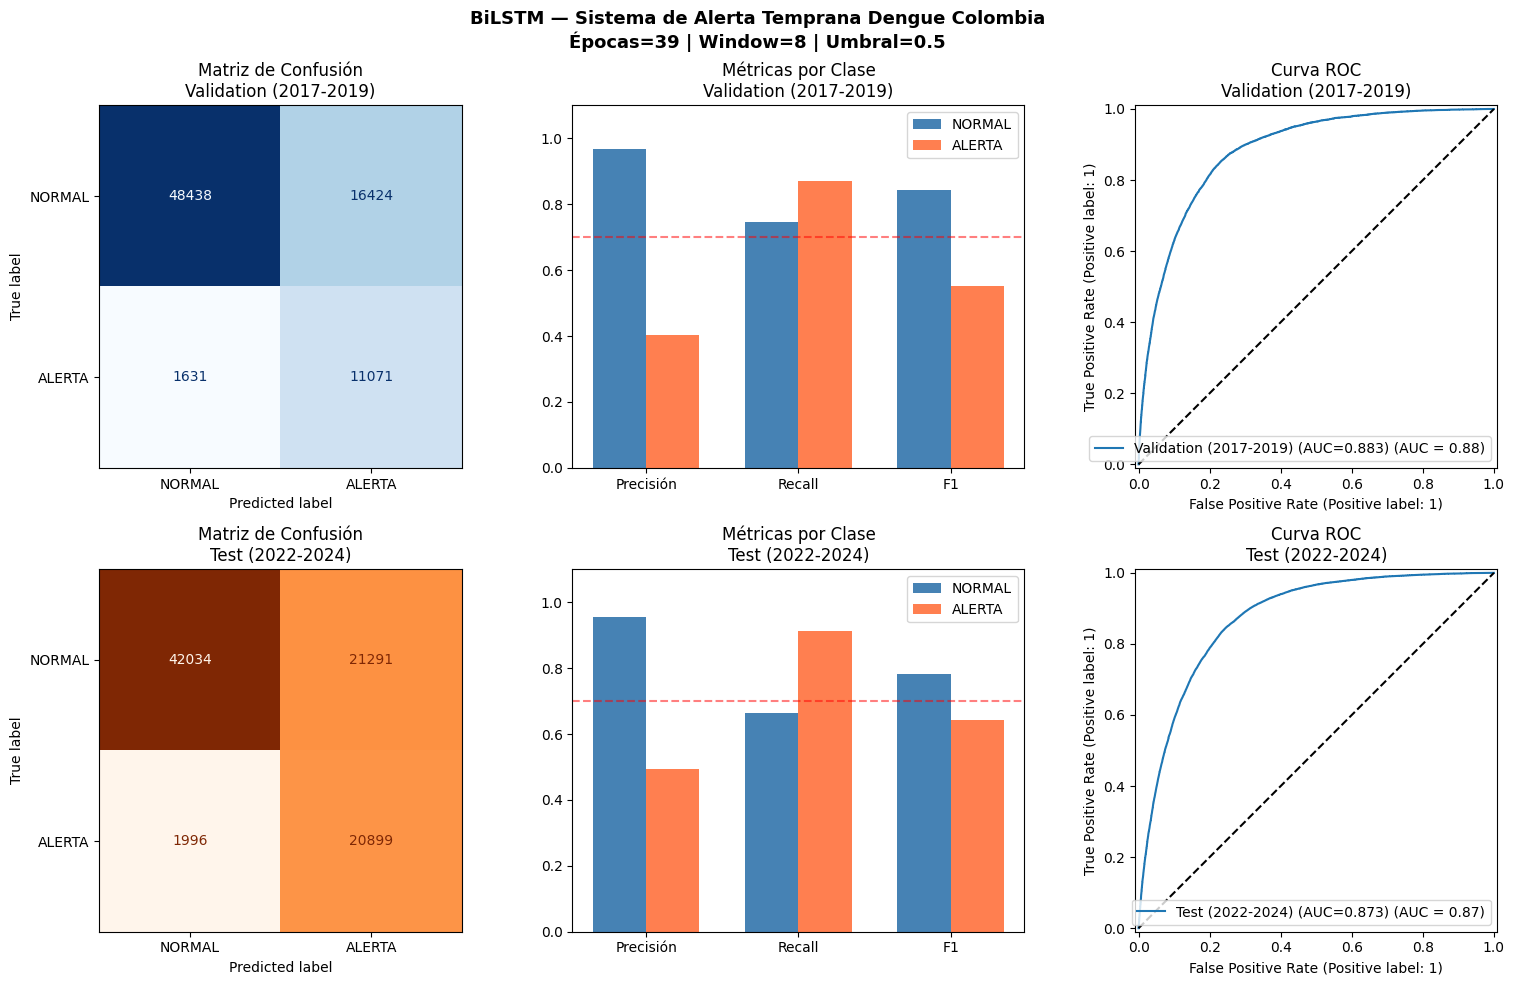

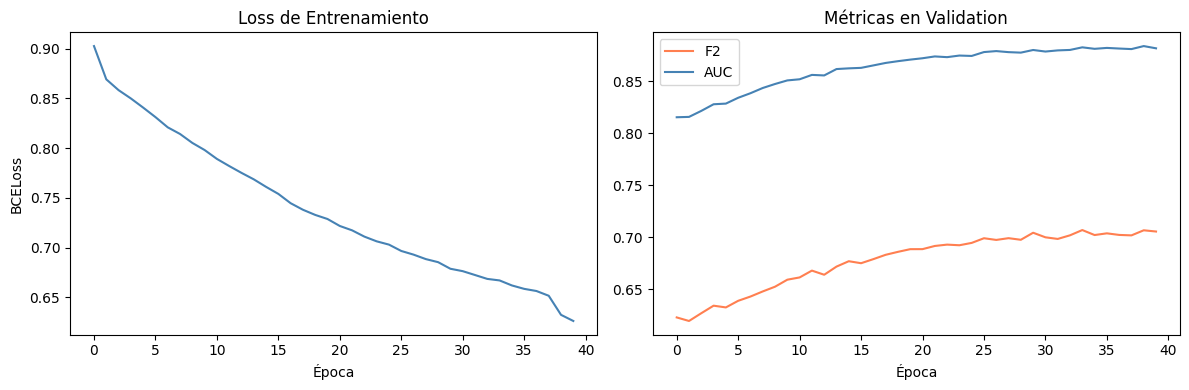

In [ ]:
# ── Cargar mejor modelo y evaluar ─────────────────────────────────────────────
modelo_bilstm.load_state_dict(torch.load('bilstm_mejor.pt'))
modelo_bilstm.eval()

# Buscar umbral óptimo en validation
probs_val, labels_val, _ = evaluar_loader(modelo_bilstm, val_loader)

res_u = []
for u in np.arange(0.1, 0.9, 0.05):
    yp = (probs_val >= u).astype(int)
    if yp.sum() == 0 or (1-yp).sum() == 0: continue
    res_u.append({
        'umbral'    : round(u, 2),
        'precision' : round(precision_score(labels_val, yp, zero_division=0), 3),
        'recall'    : round(recall_score(labels_val, yp, zero_division=0), 3),
        'f2'        : round(fbeta_score(labels_val, yp, beta=2, zero_division=0), 3),
    })

df_u = pd.DataFrame(res_u)
UMBRAL_BILSTM = df_u.loc[df_u['f2'].idxmax(), 'umbral']
print(f'Umbral óptimo BiLSTM: {UMBRAL_BILSTM}')
print(df_u.to_string(index=False))

# Evaluación en validation
y_pred_val = (probs_val >= UMBRAL_BILSTM).astype(int)
print(f'\n=== VALIDATION (2017-2019) ===')
print(classification_report(labels_val, y_pred_val,
                             target_names=['NORMAL','ALERTA'], digits=3))
print(f'F2-score : {fbeta_score(labels_val, y_pred_val, beta=2):.3f}')
print(f'AUC-ROC  : {roc_auc_score(labels_val, probs_val):.3f}')

# Evaluación en TEST
probs_te, labels_te, _ = evaluar_loader(modelo_bilstm, te_loader)
y_pred_te = (probs_te >= UMBRAL_BILSTM).astype(int)
print(f'\n=== TEST (2022-2024) ===')
print(classification_report(labels_te, y_pred_te,
                             target_names=['NORMAL','ALERTA'], digits=3))
print(f'F2-score : {fbeta_score(labels_te, y_pred_te, beta=2):.3f}')
print(f'AUC-ROC  : {roc_auc_score(labels_te, probs_te):.3f}')

# ── Comparación final de modelos ──────────────────────────────────────────────
print('\n' + '='*65)
print('COMPARACIÓN FINAL — VALIDATION y TEST')
print('='*65)
print(f'{"Modelo":<25} {"Val F2":>8} {"Val AUC":>8} {"Test F2":>8} {"Test AUC":>9}')
print('-'*65)
print(f'{"XGBoost":<25} {"0.678":>8} {"0.869":>8} {"0.762":>8} {"0.873":>9}')
print(f'{"BiLSTM":<25} '
      f'{fbeta_score(labels_val, y_pred_val, beta=2):>8.3f} '
      f'{roc_auc_score(labels_val, probs_val):>8.3f} '
      f'{fbeta_score(labels_te, y_pred_te, beta=2):>8.3f} '
      f'{roc_auc_score(labels_te, probs_te):>9.3f}')

# ── Gráficas ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('BiLSTM — Sistema de Alerta Temprana Dengue Colombia\n'
             f'Épocas=39 | Window={WINDOW} | Umbral={UMBRAL_BILSTM}',
             fontsize=13, fontweight='bold')

for fila, (y_r, y_p, y_pb, titulo, cmap) in enumerate([
    (labels_val, y_pred_val, probs_val, 'Validation (2017-2019)', 'Blues'),
    (labels_te,  y_pred_te,  probs_te,  'Test (2022-2024)',       'Oranges')
]):
    ConfusionMatrixDisplay(confusion_matrix(y_r, y_p),
                           display_labels=['NORMAL','ALERTA']).plot(
        ax=axes[fila,0], colorbar=False, cmap=cmap)
    axes[fila,0].set_title(f'Matriz de Confusión\n{titulo}')

    from sklearn.metrics import precision_recall_fscore_support
    prec, rec, f1, _ = precision_recall_fscore_support(y_r, y_p)
    x = np.arange(3); w = 0.35
    axes[fila,1].bar(x-w/2, [prec[0],rec[0],f1[0]], w, label='NORMAL',  color='steelblue')
    axes[fila,1].bar(x+w/2, [prec[1],rec[1],f1[1]], w, label='ALERTA',  color='coral')
    axes[fila,1].set_xticks(x)
    axes[fila,1].set_xticklabels(['Precisión','Recall','F1'])
    axes[fila,1].set_ylim(0, 1.1)
    axes[fila,1].set_title(f'Métricas por Clase\n{titulo}')
    axes[fila,1].legend()
    axes[fila,1].axhline(0.7, color='red', linestyle='--', alpha=0.5)

    from sklearn.metrics import RocCurveDisplay
    RocCurveDisplay.from_predictions(
        y_r, y_pb, ax=axes[fila,2],
        name=f'{titulo} (AUC={roc_auc_score(y_r,y_pb):.3f})')
    axes[fila,2].plot([0,1],[0,1],'k--')
    axes[fila,2].set_title(f'Curva ROC\n{titulo}')

plt.tight_layout()
plt.savefig('bilstm_evaluacion_completa.png', dpi=150, bbox_inches='tight')
plt.show()

# Curva de entrenamiento
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
axes2[0].plot(historial['train_loss'], color='steelblue')
axes2[0].set_title('Loss de Entrenamiento')
axes2[0].set_xlabel('Época')
axes2[0].set_ylabel('BCELoss')
axes2[1].plot(historial['val_f2'],  color='coral',     label='F2')
axes2[1].plot(historial['val_auc'], color='steelblue', label='AUC')
axes2[1].set_title('Métricas en Validation')
axes2[1].set_xlabel('Época')
axes2[1].legend()
plt.tight_layout()
plt.savefig('bilstm_curva_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()